In [29]:
# Monte Carlo simulation of 2024 tournament using saved model
import joblib
import pandas as pd
import numpy as np
from pathlib import Path

In [30]:
# Define paths for model and tournament data
MODEL_PATH = Path("models/xgb_march_madness_model.joblib")

# Path to matchup features CSV
MATCHUPS_PATH = Path("data/processed/MNCAATourneyMatchupFeatures.csv")

# Load matchup features
df_matchups = pd.read_csv(MATCHUPS_PATH)

# Load trained model
model = joblib.load(MODEL_PATH)

In [31]:
# Simulate tournament matchups from processed feature differences

# Select numeric feature columns (robust to minor column variations)
numeric_cols = df_matchups.select_dtypes(include=["number"]).columns.tolist()

# If a known expected feature set exists, intersect to ensure order
expected_feat_cols = [
    "eFG_diff", "TOVp_diff", "ORBp_diff", "FTR_diff",
    "ORtg_diff", "DRtg_diff", "win_rate_diff", "seed_num_diff",
]
feat_cols = [c for c in expected_feat_cols if c in numeric_cols]
if not feat_cols:
    # Fall back to using all numeric columns
    feat_cols = numeric_cols

# Prefer the exact feature names used by the trained model when available
feat_names = getattr(model, "feature_names_in_", None)
if feat_names is not None:
    # Keep only those the model expects; preserve order
    feat_cols = [c for c in feat_names if c in (set(numeric_cols) | set(expected_feat_cols))]
    # If still empty for any reason, keep the earlier detection
    if not feat_cols:
        feat_cols = list(feat_names)

In [86]:
# Build and simulate the NCAA bracket using Seeds and Slots
import re
from collections import defaultdict, deque

# Paths to Kaggle data and team features
DATA_ROOT = Path("data/relevant_data")
SEEDS_PATH = DATA_ROOT / "MNCAATourneySeeds.csv"
SLOTS_PATH = DATA_ROOT / "MNCAATourneySlots.csv"
TEAMS_PATH = DATA_ROOT / "MTeams.csv"
TEAM_FEATURES_PATH = Path("data/processed/team_data.csv")

# Load datasets
seeds_df = pd.read_csv(SEEDS_PATH)
slots_df = pd.read_csv(SLOTS_PATH)
teams_df = pd.read_csv(TEAMS_PATH)

# Optional: team-level features per season for feature diffs
team_feat_df = None
if TEAM_FEATURES_PATH.exists():
    team_feat_df = pd.read_csv(TEAM_FEATURES_PATH)

# Choose the season to simulate: prefer 2024 if available else the latest in common
available_seasons = sorted(set(seeds_df["Season"]).intersection(set(slots_df["Season"])))
latest_season = 2025#2024 if 2024 in available_seasons else max(available_seasons)

# Filter season data
seeds = seeds_df[seeds_df["Season"] == latest_season].copy()
slots = slots_df[slots_df["Season"] == latest_season].copy()

# Helpers
seed_num_re = re.compile(r"^[WXYZ](\d{2})[ab]?$", re.I)

def seed_number(seed_str: str) -> int:
    m = seed_num_re.match(seed_str)
    return int(m.group(1)) if m else 99

# Map seed -> team for the season (includes play-in a/b seeds)
seed_to_teamid = dict(zip(seeds["Seed"], seeds["TeamID"]))

# Map TeamID -> TeamName for pretty printing
team_name = dict(zip(teams_df["TeamID"], teams_df["TeamName"]))

# Optionally, build per-season team features for quick access
team_features = {}
if team_feat_df is not None and "Season" in team_feat_df.columns and "TeamID" in team_feat_df.columns:
    # keep only this season if present
    tf = team_feat_df.copy()
    if latest_season in set(tf.get("Season", pd.Series([], dtype=int))):
        tf = tf[tf["Season"] == latest_season]
    for _, r in tf.iterrows():
        team_features[int(r["TeamID"])] = r.to_dict()

# Determine which base stat columns we can use to construct diffs
base_feat_cols = ["eFG", "TOVp", "ORBp", "FTR", "ORtg", "DRtg", "win_rate"]
avail_cols = []
if team_features:
    # Inspect any one row to detect available columns
    sample = next(iter(team_features.values()))
    avail_cols = [c for c in base_feat_cols if c in sample]

# Construct a single-row feature vector for a matchup (A vs B)
# Returns: (X_df[feat_cols], feature_column_names actually provided)
def build_feature_row(team_a: int, team_b: int, seed_a: str, seed_b: str):
    row_vals = {}

    # From team features if available
    if avail_cols:
        fa = team_features.get(team_a, {})
        fb = team_features.get(team_b, {})
        for c in avail_cols:
            row_vals[f"{c}_diff"] = float(fa.get(c, np.nan)) - float(fb.get(c, np.nan))

    # Seed number diff (align with training: positive favors Team A)
    # Training used seed_num_diff = seed2 - seed1 (Team1 advantage -> positive)
    row_vals["seed_num_diff"] = seed_number(seed_b) - seed_number(seed_a)

    # From precomputed matchup features CSV if present and provides more fields
    # Try to find a direct row for this exact A,B pair (any reasonable column naming)
    # This is optional enrichment; we'll only add fields that aren't already present
    candidate = None
    if 'Season' in df_matchups.columns:
        # Try common id column names
        id_pairs = [
            ("TeamAID", "TeamBID"), ("Team1ID", "Team2ID"), ("A_TeamID", "B_TeamID"),
        ]
        for ca, cb in id_pairs:
            if ca in df_matchups.columns and cb in df_matchups.columns:
                sub = df_matchups[(df_matchups["Season"] == latest_season) &
                                  (df_matchups[ca] == team_a) & (df_matchups[cb] == team_b)]
                if not sub.empty:
                    candidate = sub.iloc[0].to_dict()
                    break
    if candidate is not None:
        for k, v in candidate.items():
            if k.endswith("_diff") and k not in row_vals and isinstance(v, (int, float, np.floating)):
                row_vals[k] = float(v)

    # Build DataFrame with only the columns our model will consume
    # Use feat_cols computed earlier, but only those present in row_vals
    use_cols = [c for c in feat_cols if c in row_vals]
    # If nothing matched, fall back to any numeric diffs we computed
    if not use_cols:
        use_cols = [k for k in row_vals.keys() if k.endswith("_diff") or k == "seed_num_diff"]

    X_row = pd.DataFrame([[row_vals.get(c, 0.0) for c in use_cols]], columns=use_cols)
    return X_row, use_cols

# ---- Probability calibration helpers ----
# Calibrated column index for "Team A wins"
_WIN_COL = int(np.where(getattr(model, "classes_", np.array([0, 1])) == 1)[0][0]) if hasattr(model, "classes_") else 1

def predict_matchup_prob(team_a: int, team_b: int, seed_a: str, seed_b: str) -> float:
    # Build both orientations
    Xa_row, cols_a = build_feature_row(team_a, team_b, seed_a, seed_b)
    Xb_row, cols_b = build_feature_row(team_b, team_a, seed_b, seed_a)

    Xa = _to_model_X(Xa_row, cols_a)
    Xb = _to_model_X(Xb_row, cols_b)

    # Probability Team A (Team1) wins is the positive class index
    pA = float(model.predict_proba(Xa)[0][_WIN_COL])
    # Use model directly for the reversed orientation too (no 1-p fallback)
    pB = float(model.predict_proba(Xb)[0][_WIN_COL])

    # Normalize in case of minor asymmetry
    # If you prefer, keep only pA and set pB = 1 - pA
    return pA

# Resolve a seed/slot reference to (team_id, original_seed_str)
winners = {}  # slot -> (team_id, original_seed_str)

def resolve(entry: str):
    # If it's a seed name in the seeds table
    if entry in seed_to_teamid:
        tid = int(seed_to_teamid[entry])
        # normalize original seed string (e.g., turn 'W16a'/'W16b' to their own strings)
        return tid, entry
    # Else, it must refer to a prior slot
    if entry in winners:
        return winners[entry]
    return None

# Topologically simulate: repeatedly scan slots and play any game whose participants are known
remaining = set(slots["Slot"].tolist())
match_meta = []  # keep some logs per game

while remaining:
    progressed = False
    for _, row in slots.iterrows():
        slot = row["Slot"]
        if slot not in remaining:
            continue
        a_ref = row["StrongSeed"]
        b_ref = row["WeakSeed"]
        ra = resolve(a_ref)
        rb = resolve(b_ref)
        if ra is None or rb is None:
            continue  # can't play yet
        team_a, seed_a = ra
        team_b, seed_b = rb

        # Predict
        p_A = predict_matchup_prob(team_a, team_b, seed_a, seed_b)
        p_B = 1.0 - p_A
        # Winner: higher win prob
        if p_A >= p_B:
            win_id, win_seed, win_p, lose_id, lose_p = team_a, seed_a, p_A, team_b, p_B
            winA = True
        else:
            win_id, win_seed, win_p, lose_id, lose_p = team_b, seed_b, p_B, team_a, p_A
            winA = False

        winners[slot] = (win_id, win_seed)
        remaining.remove(slot)
        progressed = True

        a_label = f"{team_name.get(team_a, team_a)} ({seed_a})"
        b_label = f"{team_name.get(team_b, team_b)} ({seed_b})"
        match_meta.append({
            "slot": slot,
            "A": a_label,
            "B": b_label,
            "pA": round(p_A, 4),
            "pB": round(p_B, 4),
            "winner": team_name.get(win_id, win_id),
            "winner_seed": win_seed,
            "winner_p": round(win_p, 4),
            "winA": winA,
        })
    if not progressed:
        # Safety to avoid infinite loop if data inconsistent
        break

# Determine champion: final slot is the one that's referenced by no other slot
referenced = set(slots["StrongSeed"]).union(set(slots["WeakSeed"]))
final_slots = [s for s in slots["Slot"].tolist() if s not in referenced]
champ_slot = final_slots[0] if final_slots else slots.iloc[-1]["Slot"]
champ_id, champ_seed = winners.get(champ_slot, (None, None))
champ_name = team_name.get(champ_id, str(champ_id)) if champ_id is not None else "Unknown"

print(f"Season {latest_season} champion: {champ_name} ({champ_seed})")

# Show a concise per-round summary
# Build reverse graph: for each slot, which next slot consumes it
consumers = defaultdict(list)
for _, r in slots.iterrows():
    consumers[r["StrongSeed"].item() if hasattr(r["StrongSeed"], 'item') else r["StrongSeed"]].append(r["Slot"])
    consumers[r["WeakSeed"].item() if hasattr(r["WeakSeed"], 'item') else r["WeakSeed"]].append(r["Slot"])

# Determine round number by BFS from seeds to final
round_of = {}
q = deque()
# Initial entries are the seeds that appear in any slot
seed_entries = set(slots["StrongSeed"]).union(set(slots["WeakSeed"]))
for e in seed_entries:
    if e in seed_to_teamid:  # actual seeds
        round_of[e] = 0
        q.append(e)
while q:
    e = q.popleft()
    rnum = round_of[e]
    for nxt in consumers.get(e, []):
        if nxt not in round_of:
            round_of[nxt] = rnum + 1
            q.append(nxt)

# Group matches by round number of their slot
round_matches = defaultdict(list)
for m in match_meta:
    rnd = round_of.get(m["slot"], -1)
    round_matches[rnd].append(m)

for rnd in sorted(round_matches.keys()):
    print(f"\nRound {rnd} results:")
    for m in round_matches[rnd]:
        print(f"  {m['slot']}: {m['A']} vs {m['B']} -> Winner: {m['winner']} (p={m['winner_p']})")

Season 2025 champion: Duke (W01)

Round 1 results:
  R1W2: Alabama (W02) vs Robert Morris (W15) -> Winner: Alabama (p=0.906)
  R1W3: Wisconsin (W03) vs Montana (W14) -> Winner: Wisconsin (p=0.8906)
  R1W4: Arizona (W04) vs Akron (W13) -> Winner: Arizona (p=0.8276)
  R1W5: Oregon (W05) vs Liberty (W12) -> Winner: Oregon (p=0.7791)
  R1W6: BYU (W06) vs VCU (W11) -> Winner: BYU (p=0.6801)
  R1W7: St Mary's CA (W07) vs Vanderbilt (W10) -> Winner: St Mary's CA (p=0.7751)
  R1W8: Mississippi St (W08) vs Baylor (W09) -> Winner: Mississippi St (p=0.715)
  R1X1: Houston (X01) vs SIUE (X16) -> Winner: Houston (p=0.9215)
  R1X2: Tennessee (X02) vs Wofford (X15) -> Winner: Tennessee (p=0.906)
  R1X3: Kentucky (X03) vs Troy (X14) -> Winner: Kentucky (p=0.8906)
  R1X4: Purdue (X04) vs High Point (X13) -> Winner: Purdue (p=0.8276)
  R1X5: Clemson (X05) vs McNeese St (X12) -> Winner: Clemson (p=0.7791)
  R1X7: UCLA (X07) vs Utah St (X10) -> Winner: UCLA (p=0.7751)
  R1X8: Gonzaga (X08) vs Georgia (X09

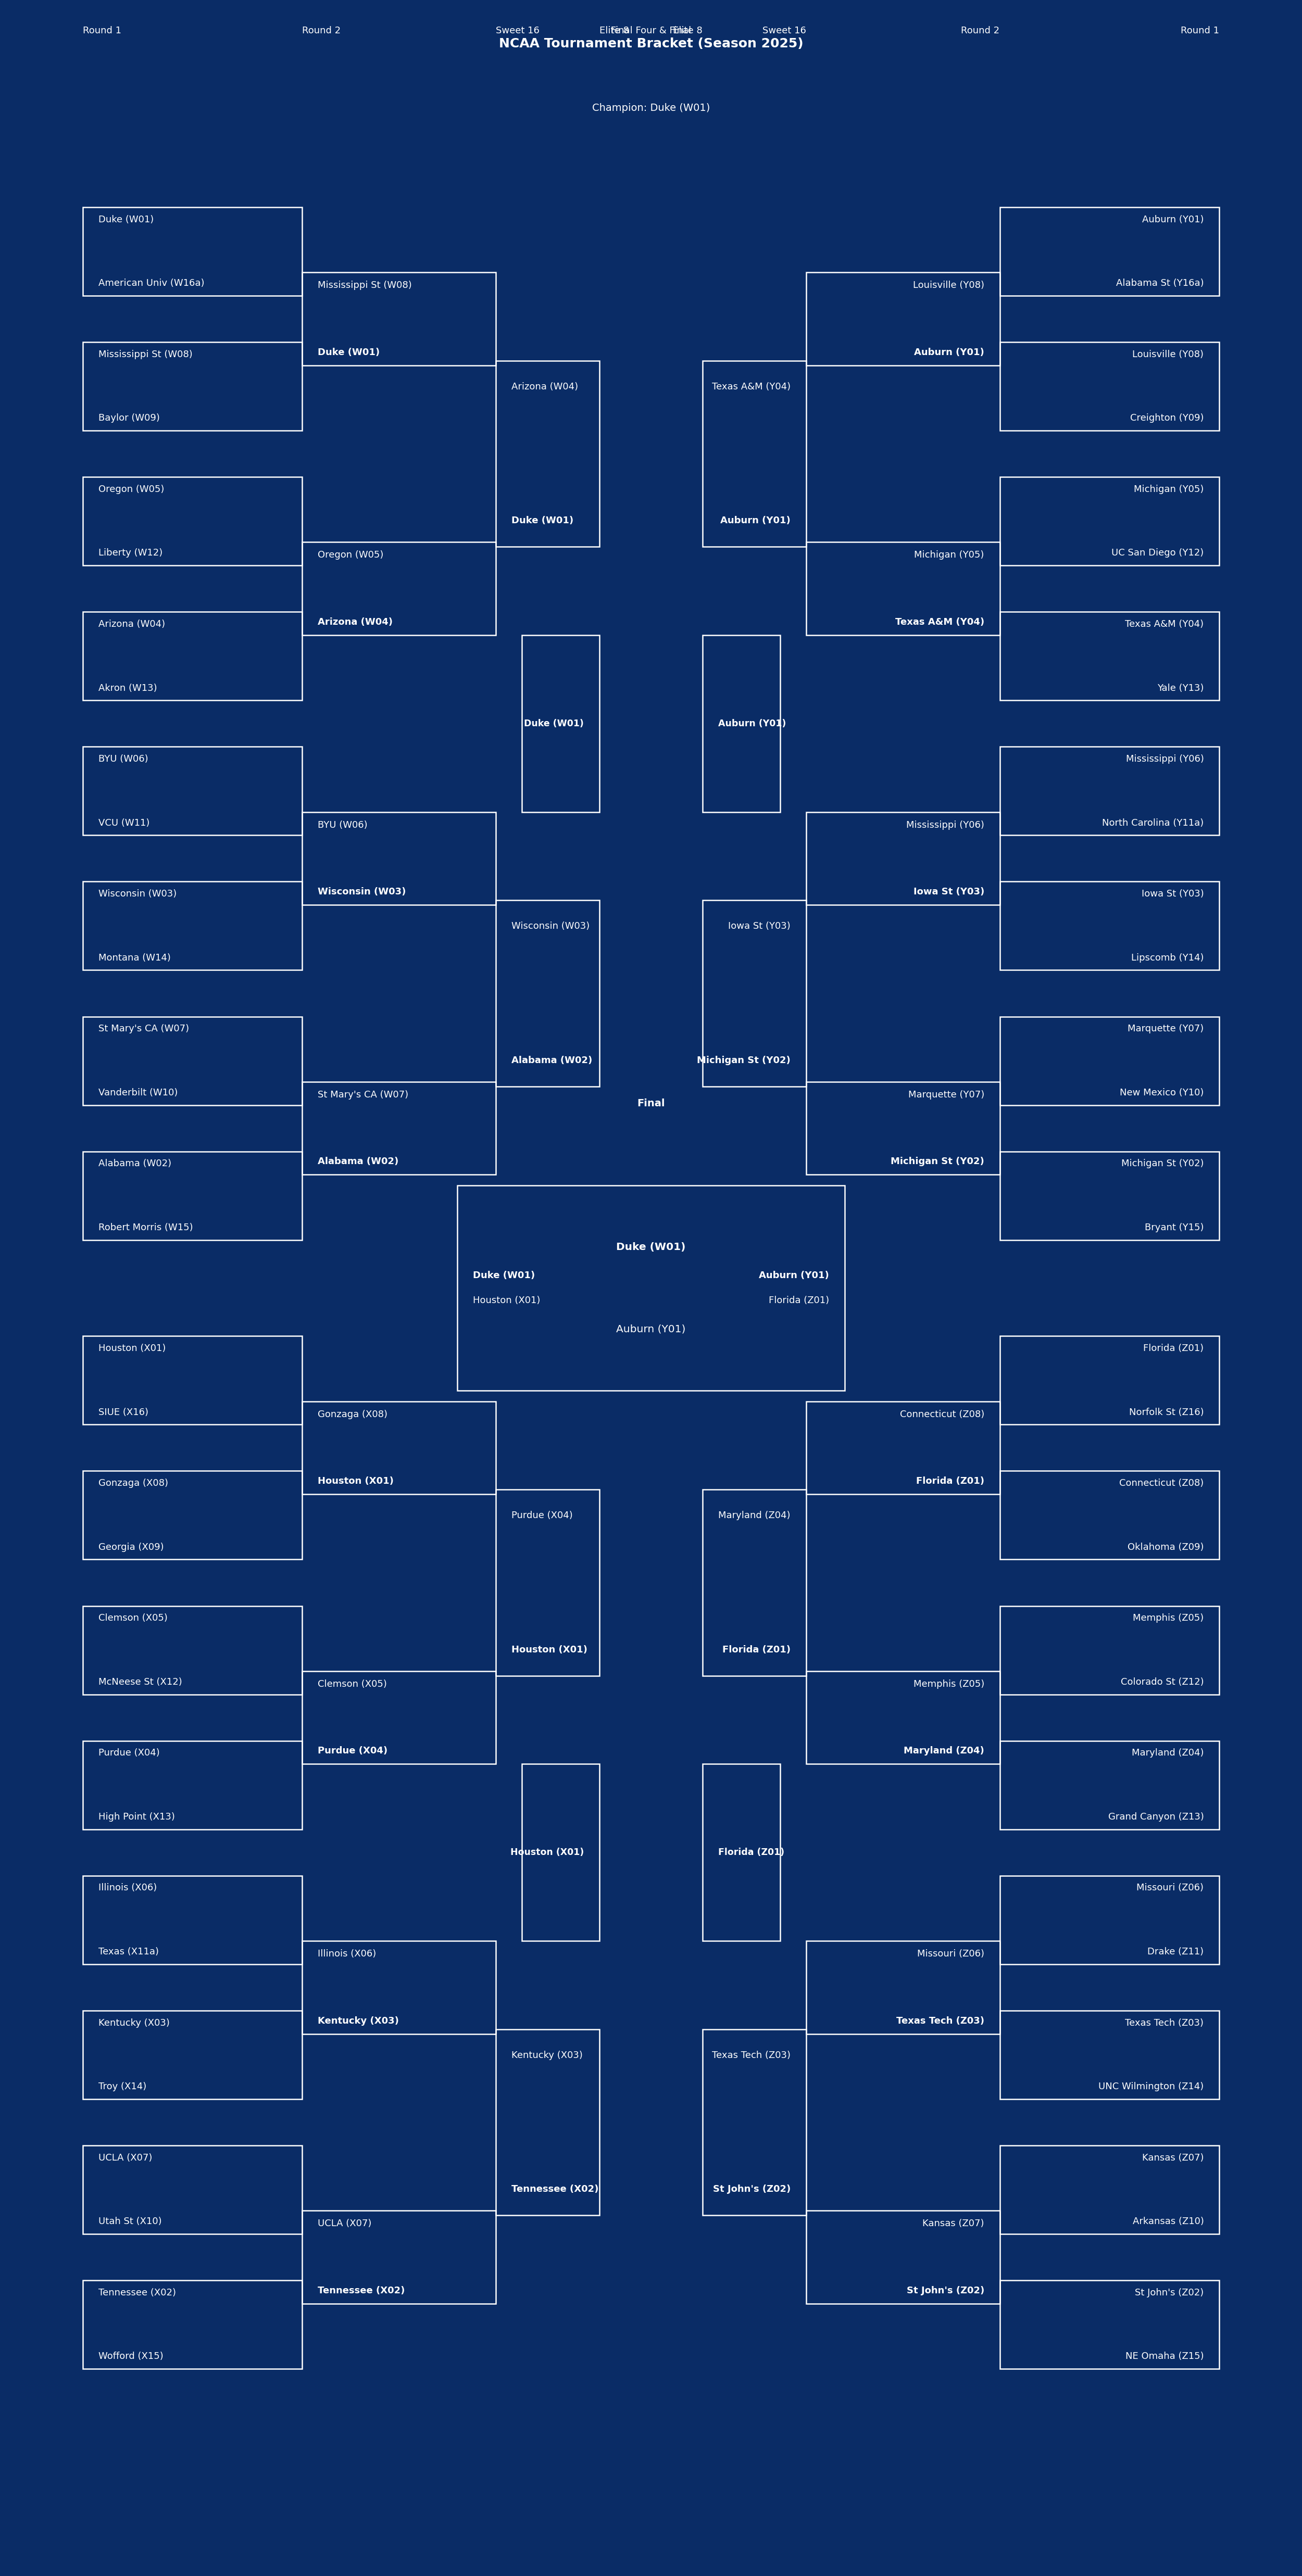

In [87]:
# Render a finished bracket image using results from cell 4 (boxed matchups and centered alignment)
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- Helpers to parse labels ---
seed_pat = re.compile(r"\(([^)]+)\)$")

def parse_seed(label: str) -> str:
    m = seed_pat.search(label)
    return m.group(1) if m else ""

def seed_region(seed: str) -> str:
    return seed[:1].upper() if seed else ""

def seed_num(seed: str) -> int:
    s = seed.rstrip('abAB')
    if s and s[0].isalpha():
        s = s[1:]
    try:
        return int(s)
    except Exception:
        return 99

# Canonical first-round pair order within a region
canonical_pairs = [(1,16),(8,9),(5,12),(4,13),(6,11),(3,14),(7,10),(2,15)]
order_index = {tuple(sorted(p)): i for i, p in enumerate(canonical_pairs)}
# Map a single seed number to its Round 1 pair index
seed_to_pair_idx = {s:i for i,(a,b) in enumerate(canonical_pairs) for s in (a,b)}

left_regions = ['W', 'X']
right_regions = ['Y', 'Z']
all_regions = left_regions + right_regions

# Build round 1 pairs per region (skip play-ins)
r1_matches = [m for m in match_meta if round_of.get(m['slot'], -1) == 1]
region_pairs = {r: [] for r in all_regions}
for m in r1_matches:
    sA = parse_seed(m['A']); sB = parse_seed(m['B'])
    rA = seed_region(sA); rB = seed_region(sB)
    if rA and rA == rB and rA in region_pairs:
        idx = order_index.get(tuple(sorted((seed_num(sA), seed_num(sB)))), None)
        if idx is None:
            continue
        region_pairs[rA].append({'idx': idx, 'A': m['A'], 'B': m['B']})
for r in region_pairs:
    region_pairs[r].sort(key=lambda x: x['idx'])
    region_pairs[r] = region_pairs[r][:8]

# Collect matches per round per region
region_rounds = {r: {1: [], 2: [], 3: [], 4: []} for r in all_regions}
for m in match_meta:
    sA = parse_seed(m['A']); sB = parse_seed(m['B'])
    rA = seed_region(sA); rB = seed_region(sB)
    rnd = round_of.get(m['slot'], -1)
    if rA == rB and rA in region_rounds and rnd in (1,2,3,4):
        region_rounds[rA][rnd].append(m)

# We'll place later rounds using canonical grouping by predecessor pairs
# Sort for reproducibility, but actual placement uses seed-derived indices
for r in all_regions:
    for rnd in (2,3,4):
        region_rounds[r][rnd].sort(key=lambda m: min(seed_num(parse_seed(m['A'])), seed_num(parse_seed(m['B']))))

regional_champs = {r: None for r in all_regions}
for r in all_regions:
    if region_rounds[r][4]:
        mm = region_rounds[r][4][0]
        regional_champs[r] = (mm['winner'], mm['winner_seed'])

# Final Four and Final
final_four = []
final_match = None
for m in match_meta:
    sA = parse_seed(m['A']); sB = parse_seed(m['B'])
    rA = seed_region(sA); rB = seed_region(sB)
    rnd = round_of.get(m['slot'], -1)
    if rnd >= 5 and (not rA or not rB or rA != rB):
        if rnd == 5:
            final_four.append(m)
        else:
            final_match = m

# --- Layout parameters ---
fig_w, fig_h = 16, 8
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.set_axis_off()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_facecolor('#0A2C66')
fig.patch.set_facecolor('#0A2C66')
text_color = 'white'

# Column x-positions (ensure gap around center)
cols_left = [0.06, 0.23, 0.38, 0.46]   # Round 1, 2, Sweet 16, Elite 8 (left stays < 0.50)
cols_center = 0.50
cols_right = [0.94, 0.77, 0.62, 0.54]  # Round 1, 2, Sweet 16, Elite 8 (right stays > 0.50)

# Region bands (top -> bottom)
band_left = {'W': (0.92, 0.52), 'X': (0.48, 0.08)}
band_right = {'Y': (0.92, 0.52), 'Z': (0.48, 0.08)}

# Draw a rectangular box ensuring x_left < x_right

def draw_box(x_left, x_right, y_center, height, edge='white', face='none', lw=1.8):
    xl, xr = (x_left, x_right) if x_left <= x_right else (x_right, x_left)
    w = (xr - xl)
    rect = patches.Rectangle((xl, y_center - height/2.0), w, height,
                             linewidth=lw, edgecolor=edge, facecolor=face)
    ax.add_patch(rect)
    return xl, xr

# Draw two team lines inside a box centered at y_center
# winner_idx: 0 -> first line bold, 1 -> second line bold, None -> none bold

def draw_boxed_match(x_left, x_right, y_center, box_h, team1, team2, align='left', winner_idx=None, fontsize=13):
    inset = 0.012
    xl, xr = draw_box(x_left, x_right, y_center, box_h)
    # Reduce gap so the two team names sit closer together within the box
    y_gap = box_h * 0.36
    if align == 'right':
        x_text = xr - inset
        ha = 'right'
    elif align == 'center':
        x_text = (xl + xr) / 2.0
        ha = 'center'
    else:
        x_text = xl + inset
        ha = 'left'
    fw1 = 'bold' if winner_idx == 0 else 'normal'
    fw2 = 'bold' if winner_idx == 1 else 'normal'
    ax.text(x_text, y_center + y_gap, team1, color=text_color, ha=ha, va='center', fontsize=fontsize, fontweight=fw1)
    ax.text(x_text, y_center - y_gap, team2, color=text_color, ha=ha, va='center', fontsize=fontsize, fontweight=fw2)

# Draw per-region rounds: boxed matchups and centered y-positions

def draw_region(region: str, side: str):
    # Choose positions
    if side == 'left':
        x_cols = cols_left
        y_top, y_bot = band_left[region]
        align = 'left'
    else:
        x_cols = cols_right
        y_top, y_bot = band_right[region]
        align = 'right'

    pairs = region_pairs.get(region, [])
    n_pairs = len(pairs)
    if n_pairs == 0:
        return {'ys_r1': [], 'ys_r2': [], 'ys_r3': [], 'y_ch': None}

    # Round 1 vertical spacing: compute centers per pair, and inner team gap
    H = abs(y_top - y_bot)
    step = H / n_pairs
    # Add vertical band padding
    band_pad = step * 0.18
    inner_gap1 = step * 0.46   # distance between the two team lines inside a R1 box
    box_h_r1 = inner_gap1 * 1.5
    pair_centers = np.linspace(y_top - step/2 + band_pad, y_bot + step/2 - band_pad, n_pairs)

    # Place Round 1 boxed matches
    ys_r1 = []
    for i in range(n_pairs):
        rec = pairs[i]
        y_mid = pair_centers[i]
        ys_r1.append(y_mid)
        draw_boxed_match(x_cols[0], x_cols[1], y_mid, box_h_r1, rec['A'], rec['B'], align=align, winner_idx=None, fontsize=13)

    # Compute Round 2 centers: between consecutive R1 pair centers
    ys_r2 = [ (ys_r1[2*k] + ys_r1[2*k+1]) / 2.0 for k in range(max(1, n_pairs//2)) ]
    inner_gap2 = (ys_r1[1] - ys_r1[0]) * 0.46 if n_pairs > 1 else inner_gap1
    box_h_r2 = inner_gap2 * 1.5

    # Map each Round 2 match to its correct center using seed-derived pair indices
    matches_r2 = region_rounds[region][2]
    for m in matches_r2:
        sA = seed_num(parse_seed(m['A'])); sB = seed_num(parse_seed(m['B']))
        pA = seed_to_pair_idx.get(sA, 0); pB = seed_to_pair_idx.get(sB, 0)
        grp = min(pA, pB) // 2
        if grp < len(ys_r2):
            y = ys_r2[grp]
            winner_idx = 0 if m.get('winA', False) else 1
            draw_boxed_match(x_cols[1], x_cols[2], y, box_h_r2, m['A'], m['B'], align=align, winner_idx=winner_idx, fontsize=13)

    # Round 3 centers: between consecutive R2 centers
    ys_r3 = [ (ys_r2[2*k] + ys_r2[2*k+1]) / 2.0 for k in range(max(1, len(ys_r2)//2)) ]
    inner_gap3 = (ys_r2[1] - ys_r2[0]) * 0.46 if len(ys_r2) > 1 else inner_gap2
    box_h_r3 = inner_gap3 * 1.5

    matches_r3 = region_rounds[region][3]
    for m in matches_r3:
        sA = seed_num(parse_seed(m['A'])); sB = seed_num(parse_seed(m['B']))
        pA = seed_to_pair_idx.get(sA, 0); pB = seed_to_pair_idx.get(sB, 0)
        grp2 = (min(pA, pB) // 2) // 2  # group of four R1 pairs
        if grp2 < len(ys_r3):
            y = ys_r3[grp2]
            winner_idx = 0 if m.get('winA', False) else 1
            draw_boxed_match(x_cols[2], x_cols[3], y, box_h_r3, m['A'], m['B'], align=align, winner_idx=winner_idx, fontsize=13)

    # Regional champion (Elite 8) box centered between the two R3 matchups
    champ = regional_champs.get(region)
    y_ch = None
    if champ:
        if len(ys_r3) >= 2:
            y_ch = (ys_r3[0] + ys_r3[1]) / 2.0
        elif ys_r3:
            y_ch = ys_r3[0]
        else:
            y_ch = np.mean([y_top, y_bot])
        # Small box reaching toward center showing champ label (leave gap to center)
        if side == 'left':
            draw_box(x_cols[3]-0.06, x_cols[3], y_ch, box_h_r3*0.95)
            ax.text(x_cols[3]-0.012, y_ch, f"{champ[0]} ({champ[1]})", color=text_color, ha='right', va='center', fontsize=12.5, fontweight='bold')
        else:
            draw_box(x_cols[3], x_cols[3]+0.06, y_ch, box_h_r3*0.95)
            ax.text(x_cols[3]+0.012, y_ch, f"{champ[0]} ({champ[1]})", color=text_color, ha='left', va='center', fontsize=12.5, fontweight='bold')

    return {'ys_r1': ys_r1, 'ys_r2': ys_r2, 'ys_r3': ys_r3, 'y_ch': y_ch}

# Draw regions and collect champion y-positions
pos_left = {}
for r in left_regions:
    pos_left[r] = draw_region(r, side='left')
pos_right = {}
for r in right_regions:
    pos_right[r] = draw_region(r, side='right')

# Compute semifinal centers: between region champions
y_sem_left = None
y_sem_right = None
if pos_left.get('W', {}).get('y_ch') is not None and pos_left.get('X', {}).get('y_ch') is not None:
    y_sem_left = (pos_left['W']['y_ch'] + pos_left['X']['y_ch']) / 2.0
if pos_right.get('Y', {}).get('y_ch') is not None and pos_right.get('Z', {}).get('y_ch') is not None:
    y_sem_right = (pos_right['Y']['y_ch'] + pos_right['Z']['y_ch']) / 2.0

# Add vertical padding between semis and the final to avoid center overlap
center_pad = 0.08
if y_sem_left is not None:
    y_sem_left -= center_pad
if y_sem_right is not None:
    y_sem_right += center_pad

# Remove Final Four boxes (semifinals) and embed them inside the Final box instead
# Draw Final: one larger box containing the two semifinal matchups on their respective sides
if final_match and y_sem_left is not None and y_sem_right is not None:
    y_final = (y_sem_left + y_sem_right) / 2.0
    final_width = 0.30
    final_height = 0.08  # reduced to ~half the previous height
    xl, xr = draw_box(cols_center-final_width/2, cols_center+final_width/2, y_final, final_height)

    # Final label above the box with padding
    ax.text(cols_center, y_final + (final_height/2) + 0.030, "Final", color=text_color, ha='center', va='bottom', fontsize=14, fontweight='bold')

    inset = 0.012
    # Center semifinal matchups vertically within the final box
    semi_line_gap = final_height * 0.06
    # Left semifinal inside final box (kept on left side)
    if len(final_four) >= 1:
        m_left = final_four[0]
        y1 = y_final + semi_line_gap
        y2 = y_final - semi_line_gap
        fw1 = 'bold' if m_left.get('winA', False) else 'normal'
        fw2 = 'bold' if not m_left.get('winA', False) else 'normal'
        ax.text(xl + inset, y1, m_left['A'], color=text_color, ha='left', va='center', fontsize=13, fontweight=fw1)
        ax.text(xl + inset, y2, m_left['B'], color=text_color, ha='left', va='center', fontsize=13, fontweight=fw2)

    # Right semifinal inside final box (kept on right side)
    if len(final_four) >= 2:
        m_right = final_four[1]
        y1 = y_final + semi_line_gap
        y2 = y_final - semi_line_gap
        fw1 = 'bold' if m_right.get('winA', False) else 'normal'
        fw2 = 'bold' if not m_right.get('winA', False) else 'normal'
        ax.text(xr - inset, y1, m_right['A'], color=text_color, ha='right', va='center', fontsize=13, fontweight=fw1)
        ax.text(xr - inset, y2, m_right['B'], color=text_color, ha='right', va='center', fontsize=13, fontweight=fw2)

    # Finalists centered inside the same box
    y_gap = final_height * 0.20
    fwA = 'bold' if final_match.get('winA', False) else 'normal'
    fwB = 'bold' if not final_match.get('winA', False) else 'normal'
    ax.text(cols_center, y_final + y_gap, final_match['A'], color=text_color, ha='center', va='center', fontsize=14.5, fontweight=fwA)
    ax.text(cols_center, y_final - y_gap, final_match['B'], color=text_color, ha='center', va='center', fontsize=14.5, fontweight=fwB)

# Title and champion
ax.text(0.5, 0.985, f"NCAA Tournament Bracket (Season {latest_season})", color=text_color, ha='center', va='center', fontsize=18, fontweight='bold')
ax.text(0.5, 0.96, f"Champion: {champ_name} ({champ_seed})", color=text_color, ha='center', va='center', fontsize=14)

# Round headings
ax.text(cols_left[0], 0.99, 'Round 1', color=text_color, ha='left', va='center', fontsize=13)
ax.text(cols_left[1], 0.99, 'Round 2', color=text_color, ha='left', va='center', fontsize=13)
ax.text(cols_left[2], 0.99, 'Sweet 16', color=text_color, ha='left', va='center', fontsize=13)
ax.text(cols_left[3], 0.99, 'Elite 8', color=text_color, ha='left', va='center', fontsize=13)
ax.text(cols_center, 0.99, 'Final Four & Final', color=text_color, ha='center', va='center', fontsize=13)
ax.text(cols_right[3], 0.99, 'Elite 8', color=text_color, ha='right', va='center', fontsize=13)
ax.text(cols_right[2], 0.99, 'Sweet 16', color=text_color, ha='right', va='center', fontsize=13)
ax.text(cols_right[1], 0.99, 'Round 2', color=text_color, ha='right', va='center', fontsize=13)
ax.text(cols_right[0], 0.99, 'Round 1', color=text_color, ha='right', va='center', fontsize=13)

# plt.tight_layout()
# Increase figure size before rendering
w, h = fig.get_size_inches()
fig.set_size_inches(w * 2, h * 8, forward=True)
plt.show()